In [1]:
import os
os.listdir()


['.ipynb_checkpoints', 'hate speech detection.ipynb', 'labeled_data.csv']

In [2]:
import pandas as pd

df = pd.read_csv("labeled_data.csv")
df.head()


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [3]:
df.columns


Index(['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither',
       'class', 'tweet'],
      dtype='object')

In [4]:
df = df[['tweet', 'class']]
df.rename(columns={'tweet': 'text', 'class': 'label'}, inplace=True)
df.head()


,text,label
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [5]:
import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)
df.head()


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shayank\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,text,label,clean_text
0,!!! RT @mayasolovely: As a woman you shouldn't...,2,rt mayasolovely woman complain cleaning house ...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1,rt mleew boy dats cold tyga dwn bad cuffin dat...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1,rt urkindofbrand dawg rt sbaby life ever fuck ...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1,rt c g anderson viva based look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1,rt shenikaroberts shit hear might true might f...


In [6]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.896913455719185
              precision    recall  f1-score   support

           0       0.53      0.17      0.25       290
           1       0.92      0.97      0.94      3832
           2       0.85      0.84      0.84       835

    accuracy                           0.90      4957
   macro avg       0.76      0.66      0.68      4957
weighted avg       0.88      0.90      0.88      4957



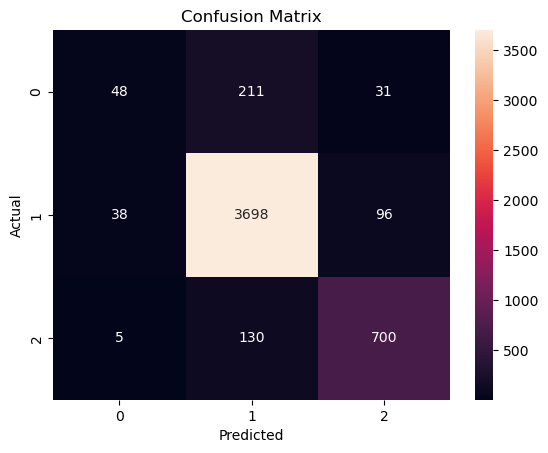

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [9]:
sample = ["I hate you so much"]
sample_clean = [clean_text(sample[0])]
sample_vec = vectorizer.transform(sample_clean)

pred = model.predict(sample_vec)
print("Hate Speech" if pred[0] == 1 else "Not Hate Speech")


Hate Speech


In [12]:
#demo output
samples = [
    "I hate you and your community",
    "Have a nice day my friend"
]

for s in samples:
    clean = clean_text(s)
    vec = vectorizer.transform([clean])
    pred = model.predict(vec)
    print(s, "->", "Hate Speech" if pred[0] == 1 else "Not Hate Speech")


I hate you and your community -> Not Hate Speech
Have a nice day my friend -> Not Hate Speech
